# Minimal Workflow Demonstration

In [2]:
import superstats as sup
import numpy as np

Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
INFO:bayesflow:Using backend 'jax'


## Constants

`NUM_STEPS` is the number of ordered trials in each simulated dataset. Set it to the length of the empirical sequences you plan to analyze, or use a common window length if sequences differ. Longer sequences can reveal slower changes in the latent parameters, but they also increase simulation, training, and memory costs.

In [3]:
# number of observations per dataset
NUM_STEPS = 100

## Specifying a Simulator

In this demonstration, the observation model is the Diffusion Decision Model (DDM), which is already implemented in `superstats`. The DDM describes a binary decision as noisy evidence accumulation. To distinguish trials from within-trial diffusion time, let $t$ index trials and let $s$ denote elapsed time during trial $t$. The latent evidence process follows the stochastic differential equation

$$
dX_t(s) = v_t \, ds + \sigma \, dW_t(s), \qquad X_t(0) = z_t a_t.
$$

Here, $W_t(s)$ is a standard Wiener process and $\sigma$ controls within-trial diffusion noise. The evidence starts between an absorbing lower boundary at $0$ and upper boundary at $a_t$. The decision time is the first-passage time, written as the infimum

$$
\operatorname{DT}_t = \inf \left\{s \geq 0 : X_t(s) \notin (0, a_t)\right\}.
$$

The infimum selects the earliest time at which the evidence reaches either threshold. The observed choice records which boundary was reached:

$$
Y_t = \begin{cases}
1, & \operatorname{DT}_t \geq a_t, \\
0, & \operatorname{DT}_t \leq 0.
\end{cases}
$$

Finally, the observed response time is the decision time plus non-decision time (NDT):

$$
\operatorname{RT}_t = \operatorname{DT}_t + \tau_t.
$$

The model parameters therefore have the following interpretations:

- $v_t$ (drift rate): the average speed and direction of evidence accumulation; its sign favors one boundary over the other.
- $a_t$ (boundary separation): response caution; larger values usually produce slower but more accurate choices.
- $\tau_t$ (non-decision time): time spent on processes outside evidence accumulation, such as stimulus encoding and motor execution.
- $z_t$ (relative starting point): prior preference for one boundary; $0.5$ places the process halfway between the bounds.

`sample_ddm` approximates the SDE with Euler–Maruyama steps. By default, it uses $\sigma=1$, a step size of `dt=0.001`, and reports a timeout if neither boundary is reached within `max_steps`.

In [4]:
obs_model = sup.simulation.sample_ddm

## Specifying a Joint Prior

The joint prior defines both plausible parameter values and how those values may evolve across trials. Each observation-model parameter can be declared in one of four ways:

- A `StochasticTransition` produces an estimated time-varying trajectory (`local_param`) and may include estimated time-invariant hyperparameters (`hyper_param`) that control its dynamics.
- A `DeterministicTransition` produces a time-varying trajectory determined by estimated or fixed hyperparameters; its values are not estimated independently at every trial.
- A `Prior` produces one estimated value shared across all trials (`shared_param`).
- A scalar fixes a value across all trials (`fixed_param`), so it is not estimated.

This example makes the following modeling choices:

- $v_t$ follows a Gaussian `RandomWalk` bounded to $[-6,6]$. Its innovation scale `v_sigma` is inferred from its default hyperprior, while the random-walk drift is fixed to its default of zero.
- $a_t$ follows a bounded `Linear` trajectory. The intercept and total change over the normalized trial index, `a_intercept` and `a_beta`, are inferred from the specified priors.
- $\tau$ has a half-normal prior and is estimated once per dataset, shared across trials.
- $z = 0.5$ is fixed, representing no initial preference for either choice boundary.

Treating every parameter as stationary would force one value to summarize the full sequence. That average can hide gradual learning or fatigue, abrupt contextual changes, and smaller trial-to-trial fluctuations that cancel out when pooled. A non-stationary model instead represents these changes as a regularized latent trajectory. It can therefore separate systematic across-trial variation from the DDM's within-trial diffusion noise and expose dynamics that are invisible in aggregate response-time and accuracy summaries.

This extra flexibility must be justified: an overly permissive transition can mistake observation noise for parameter change. Bounds, transition assumptions, and hyperpriors determine the time scale and magnitude of recoverable fluctuations, so they should encode scientifically plausible behavior and be checked with parameter-recovery and posterior-predictive diagnostics.

For stochastic transitions, trajectories are generated in an unconstrained space and transformed with a scaled sigmoid. Consequently, `initial_prior` is specified on the unconstrained scale. Deterministic trajectories such as `Linear` are clipped to their declared bounds.

In [14]:
joint_prior = sup.JointPrior(
    v=sup.transition.RandomWalk(bounds=(-6.0, 6.0)),
    a=sup.transition.Linear(
        bounds=(0.2, 4.0),
        intercept=sup.Prior("normal", loc=2.0, scale=0.5),
        beta=sup.Prior("normal", loc=0.0, scale=1.0)
    ),
    tau=sup.Prior("halfnormal", scale=0.5),
    bias=0.5
)

Inspect 20 prior parameter trajectories and 1,000 draws from the hyperparameter priors. This check helps reveal implausible ranges, excessive volatility, and frequent clipping before those assumptions are used to generate training data.

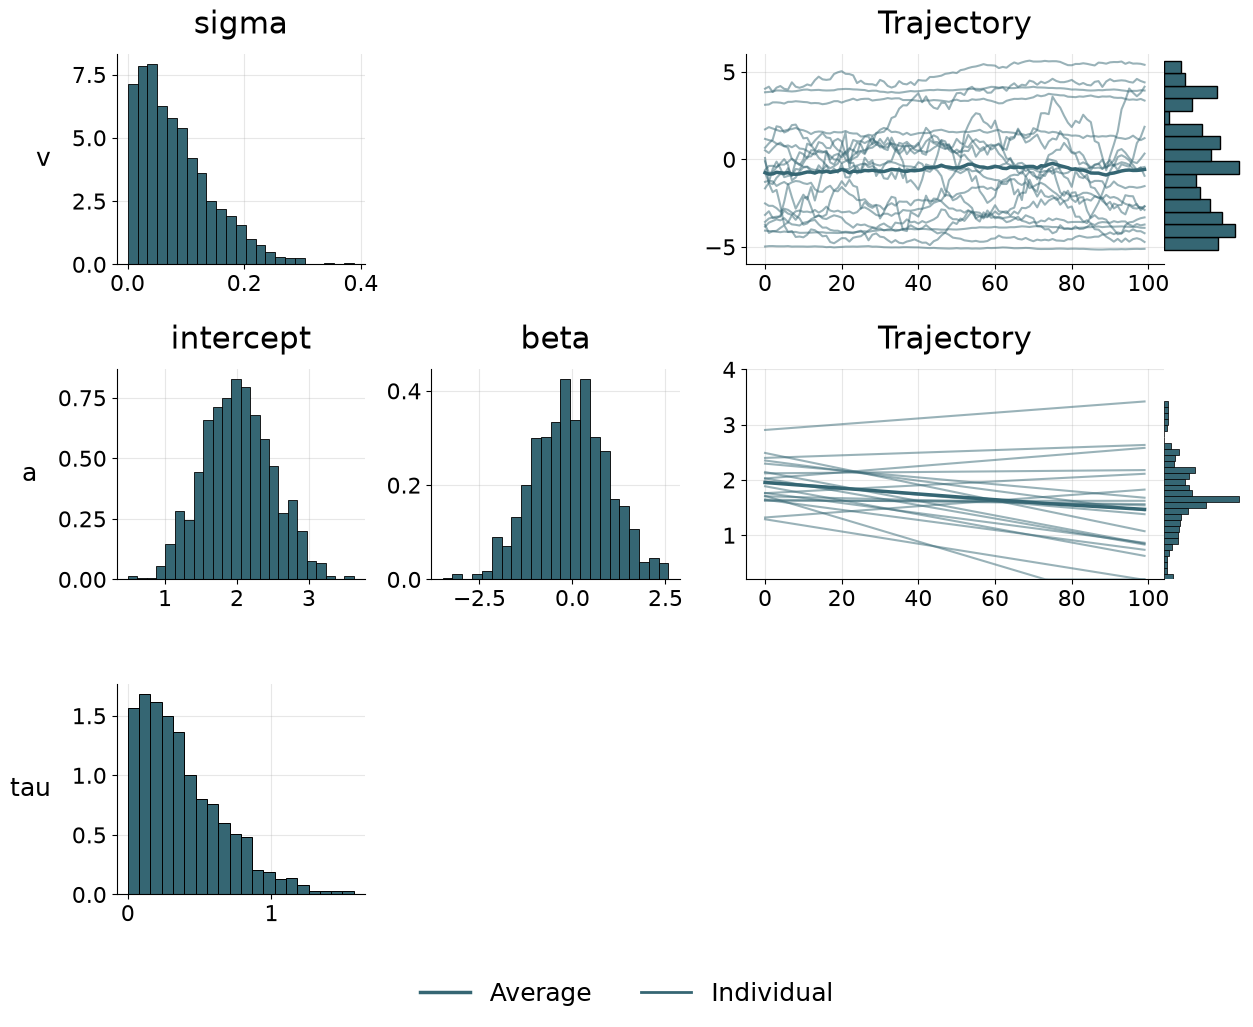

In [5]:
fig = joint_prior.plot_joint_prior(
    num_steps=NUM_STEPS,
    num_trajectories=20,
    num_draws=1000
)

## Specifying a Model

Next, combine the joint prior and observation model in a `Model`. The model can also simulate missing observations and contaminated responses, which is useful because the training data should reproduce the imperfections expected in the empirical data.

This minimal example sets both processes to `None`, so every simulated observation comes directly from the DDM. Set `missing="random"` to simulate missing-at-random (MAR) observations; the missingness probability may itself be drawn from a prior so that datasets have different missing proportions, although that probability is not currently inferred. Set `contamination="random_choice"` to include random-choice contaminants. These are substantive modeling choices: only add a process when it reflects a plausible data-generating mechanism, and use prior push-forward checks to assess the resulting data.

In [8]:
model = sup.Model(
    prior=joint_prior,
    simulator=obs_model,
    missing=None,
    contamination=None
)

Draw 10 parameter configurations from the joint prior and simulate one dataset of `NUM_STEPS` observations from each.

In [9]:
sim_data = model.sample(batch_size=10, num_steps=NUM_STEPS)

In [11]:
print(
    "Dict keys: ", sim_data.keys(), "\n",
    "Shape of response times: ", sim_data["response_time"].shape, "\n",
    "Shape of a time-varying param: ", sim_data["v"].shape, "\n",
    "Shape of a time-invariant param: ", sim_data["v_sigma"].shape, "\n",
    sep=""
)

Dict keys: dict_keys(['response_time', 'choice', 'time_steps', 'v', 'a', 'v_sigma', 'a_intercept', 'a_beta', 'tau'])
Shape of response times: (10, 100)
Shape of a time-varying param: (10, 100, 1)
Shape of a time-invariant param: (10, 1)



## Prior Push Forward Checks

A prior push-forward check asks whether the complete generative model produces plausible observations before any data are fitted. The call below draws 12 parameter configurations, simulates 12 datasets, and displays the response-time variable (`data_dim=0`) as a distribution (`kind="dist"`). Setting `aggregation=None` keeps one panel per dataset, making between-dataset variation visible. If the plots contain unrealistic response times, choices, or variability, revise the priors or transition assumptions before training.

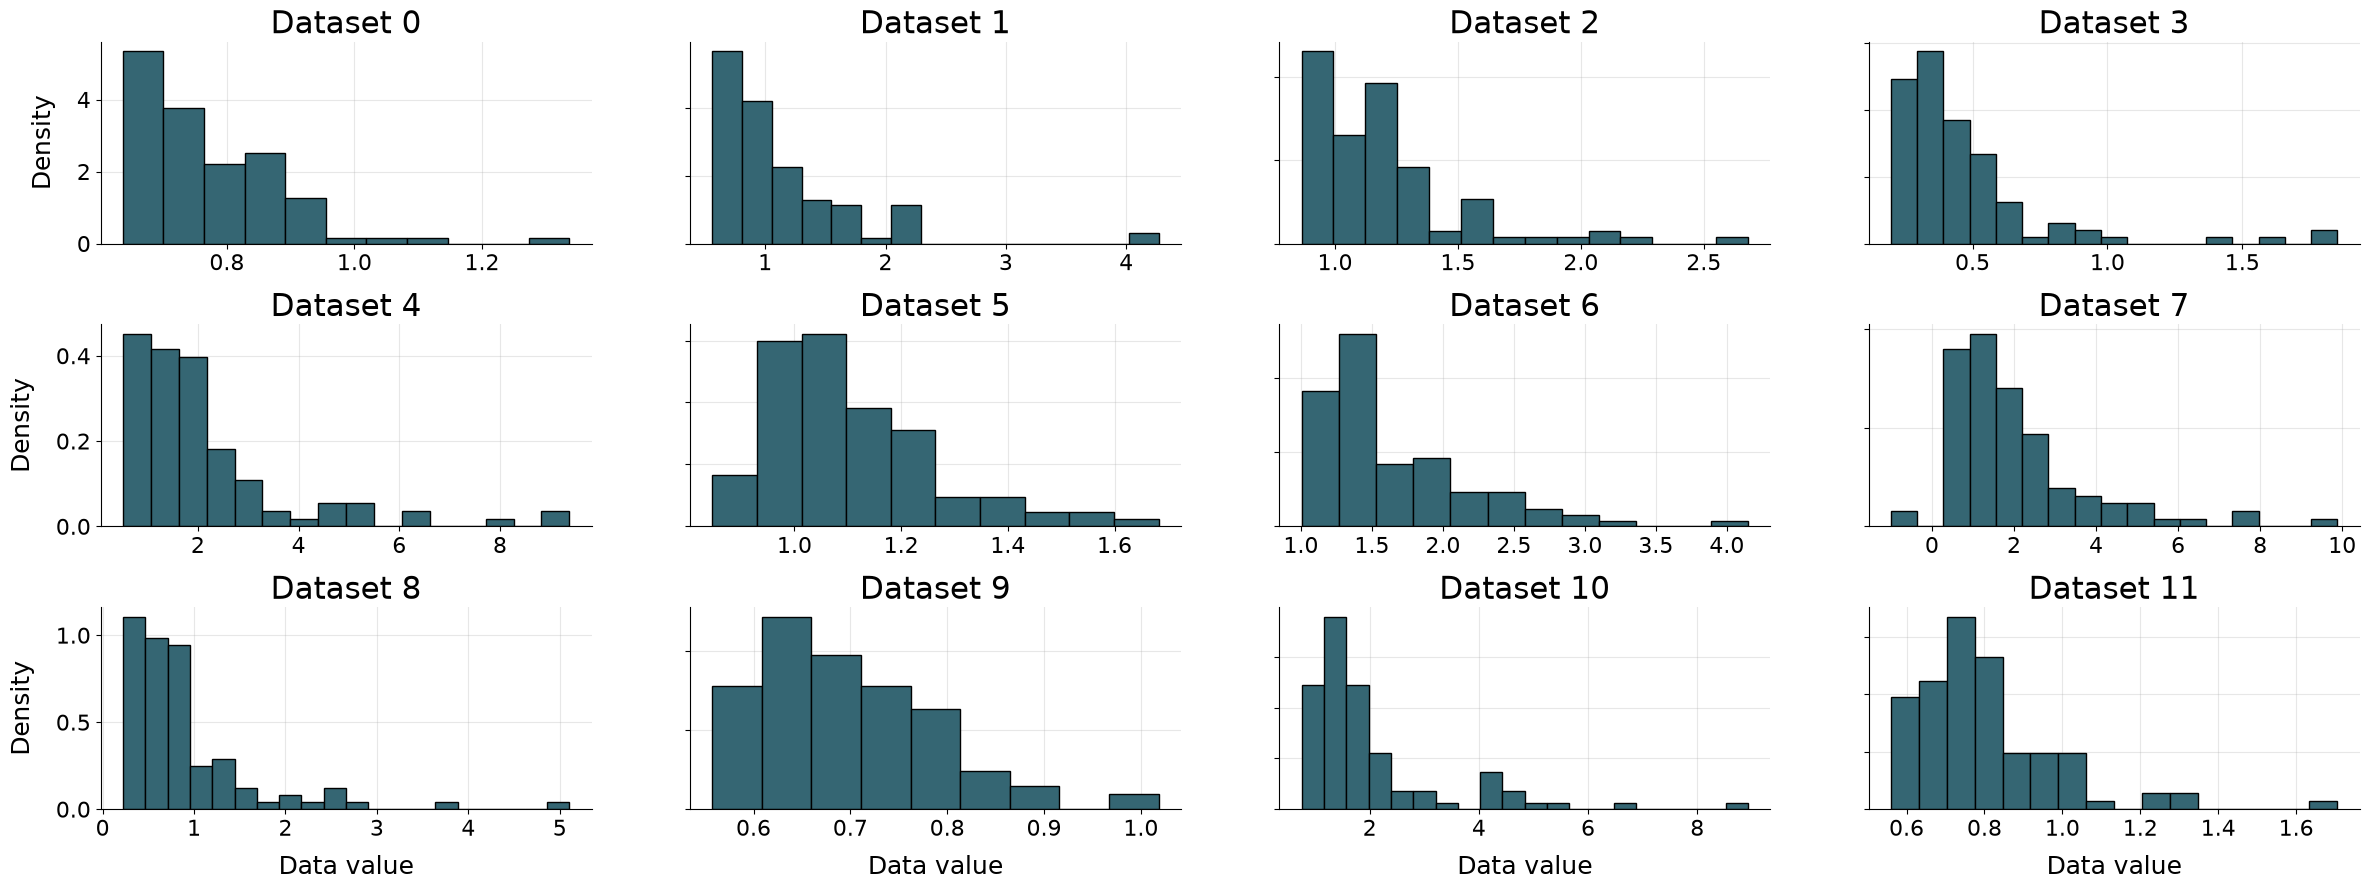

In [13]:
fig = model.plot_push_forward(
    batch_size=12,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist",
    aggregation=None
)

## Setting Up an Amortized Bayesian Workflow

In [18]:
workflow = sup.Workflow(
    model=model,
    checkpoint_filepath="checkpoints/minimal_demo",
    embedding_network=sup.networks.RecurrentNet(),
    inference_network="coupling"
)

The `Workflow` connects the generative model to a trainable posterior approximator. The recurrent embedding network is a natural choice for ordered trial sequences because it can summarize both the observations and their temporal context. The `"coupling"` inference network is a conditional normalizing flow, chosen to represent potentially complex posterior dependencies among trajectories and hyperparameters. Package defaults are used when either network is omitted; experienced users can supply custom networks when sequence length, posterior complexity, or compute constraints call for a different architecture. `checkpoint_filepath` determines where the fitted network and training history are saved and restored.

## Approximator Training

Amortized inference learns a reusable mapping from an observed sequence to an approximate posterior. During training, the model repeatedly draws parameters from the joint prior and then simulates observations:

$$
\theta^{(m)} \sim p(\theta), \qquad x^{(m)} \sim p\left(x \mid \theta^{(m)}\right).
$$

Here, $\theta$ includes the time-varying trajectories and time-invariant hyperparameters, while $x$ contains response times and choices. The network parameters $\phi$ are optimized so that the conditional density $q_\phi(\theta\mid x)$ assigns high probability to the parameters that generated each simulated dataset:

$$
\phi^\star = \arg\min_{\phi} \; \mathbb{E}_{p(\theta)p(x\mid\theta)}\left[-\log q_\phi(\theta\mid x)\right].
$$

The up-front simulation and optimization cost is the *amortization* cost. Once paid, posterior samples for many new datasets can be generated quickly without running a new Markov chain for every dataset. In contrast, MCMC usually performs many sequential likelihood evaluations for each fitted dataset; this can be slow for large collections of participants and difficult when only a simulator, rather than a convenient likelihood, is available. Amortization is therefore especially valuable for repeated inference, parameter-recovery studies, and posterior-predictive checks.

The trade-off is that the learned posterior is an approximation and is reliable only over the parameter and data regimes represented during training. Prior-predictive checks, held-out recovery, calibration diagnostics, and posterior re-simulation remain essential. Choose one of the offline or online training modes below; running both will continue training the same workflow and is only appropriate if that is intentional.

### Offline Training

Offline training simulates a fixed dataset once and reuses it across epochs. It is convenient for rapid, reproducible iteration because simulation and training are separated, but the stored data consume memory and limit the diversity of examples seen by the network. Here, `batch_size=20_000` controls the number of simulated training datasets, `epochs=50` controls how often they are revisited, and the optimization `batch_size=32` trades memory use against gradient stability. The smaller held-out validation set monitors generalization; increase it when more stable validation estimates are needed.

In [12]:
train_data = model.sample(
    batch_size=20_000,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)
val_data = model.sample(
    batch_size=100,
    num_steps=NUM_STEPS,
    tile_to_steps=True
)

Setting `tile_to_steps=True` repeats each time-invariant target along the trial dimension, changing its shape from `(batch_size, 1)` to `(batch_size, num_steps, 1)`. This aligns shared parameters with the time-varying targets expected by the recurrent approximator; it does not make those parameters time-varying.

In [ ]:
history = workflow.fit_offline(
    data=train_data,
    validation_data=val_data,
    epochs=50,
    batch_size=32
)

### Online Training

Online training generates fresh simulations for every batch. This exposes the network to a broader range of prior-predictive datasets and avoids storing a large training set, often making it preferable for a longer final training run when simulation is fast. It is less reproducible batch-for-batch and pays the simulation cost throughout training. `num_batches_per_epoch` controls the number of gradient updates per epoch, while `epochs` and `batch_size` determine the total training budget. Keep `num_steps` consistent with the sequence length used for inference, and tune all three choices by monitoring training and validation diagnostics rather than treating the values below as universal defaults.

In [ ]:
history = workflow.fit_online(
    num_steps=100, epochs=50,
    num_batches_per_epoch=1000,
    batch_size=32
)

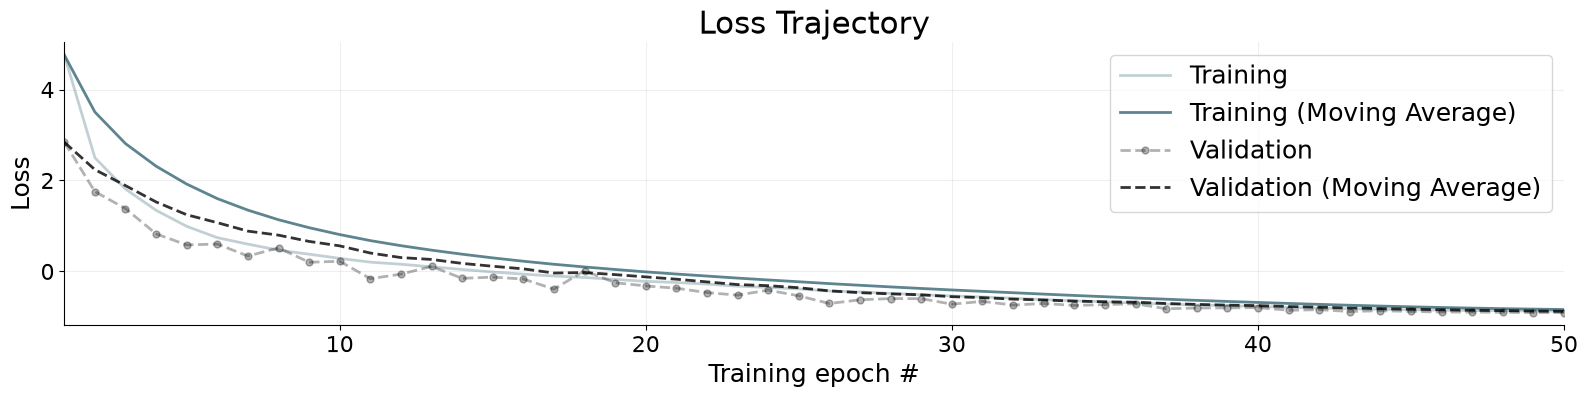

In [19]:
fig = workflow.plot_history(workflow.history)

## Model Verification

Simulate 250 held-out datasets for verification. These datasets should not be reused from training: recovery on fresh prior-predictive draws tests whether the amortized posterior generalizes across the assumed parameter space. Larger verification batches give more stable diagnostic summaries but require more simulation and inference time.

In [20]:
targets = model.sample(
    batch_size=250,
    num_steps=NUM_STEPS,
)

Draw 300 approximate posterior samples for every held-out dataset. Increasing `num_samples` reduces Monte Carlo noise in posterior summaries and diagnostics, at the cost of additional time and memory. The inference `batch_size=8` limits how many datasets are processed together and can be lowered if memory is constrained.

In [ ]:
samples = workflow.sample(
    data=targets,
    num_samples=300,
    batch_size=8
)

### Time-varying Parameters

Plot four diagnostic metrics for the time-varying parameters at every trial:

1. Pearson correlation between the true parameter and posterior median.
2. Normalized root mean squared error between the true parameter and posterior median.
3. Posterior contraction, which measures how much uncertainty is reduced relative to the prior.
4. Simulation-based calibration error, which assesses whether posterior uncertainty has the correct repeated-simulation coverage.

Inspect the full time profile rather than only its average: poor recovery at particular trials can reveal boundary effects, weak information, or fluctuations that are too rapid for the chosen transition model and network to resolve.

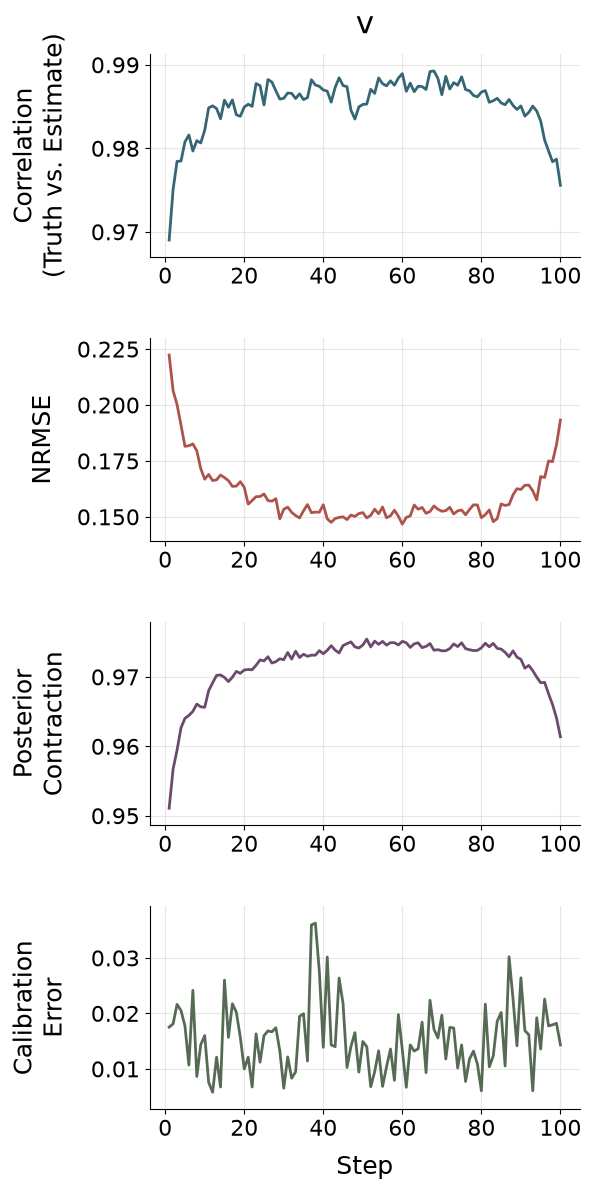

In [22]:
fig = workflow.verify_time_varying(
    targets=targets,
    estimates=samples
)

### Time-invariant Parameters

For time-invariant parameters, inspect parameter recovery, simulation-based calibration, and posterior z-scores together with contraction. Recovery measures point-estimate accuracy, calibration tests uncertainty, and contraction indicates how informative the data are relative to the prior; no single diagnostic is sufficient on its own.

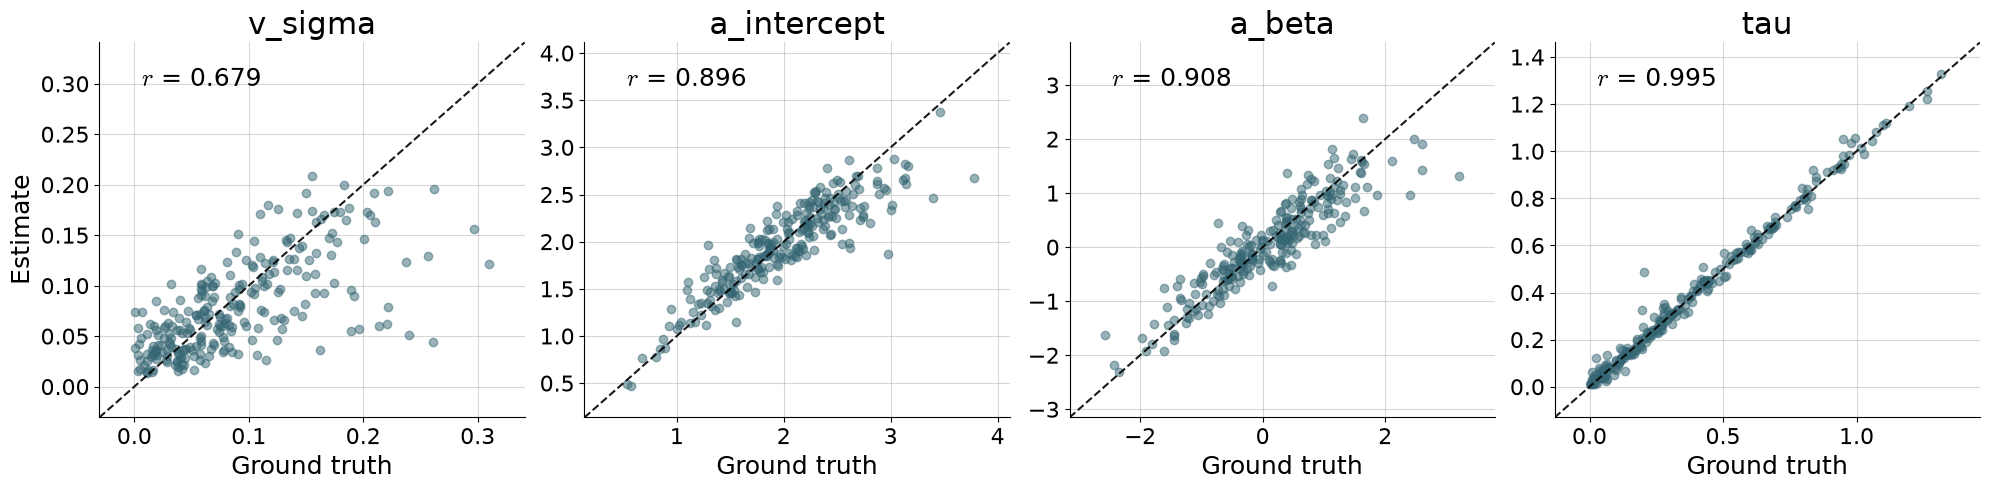

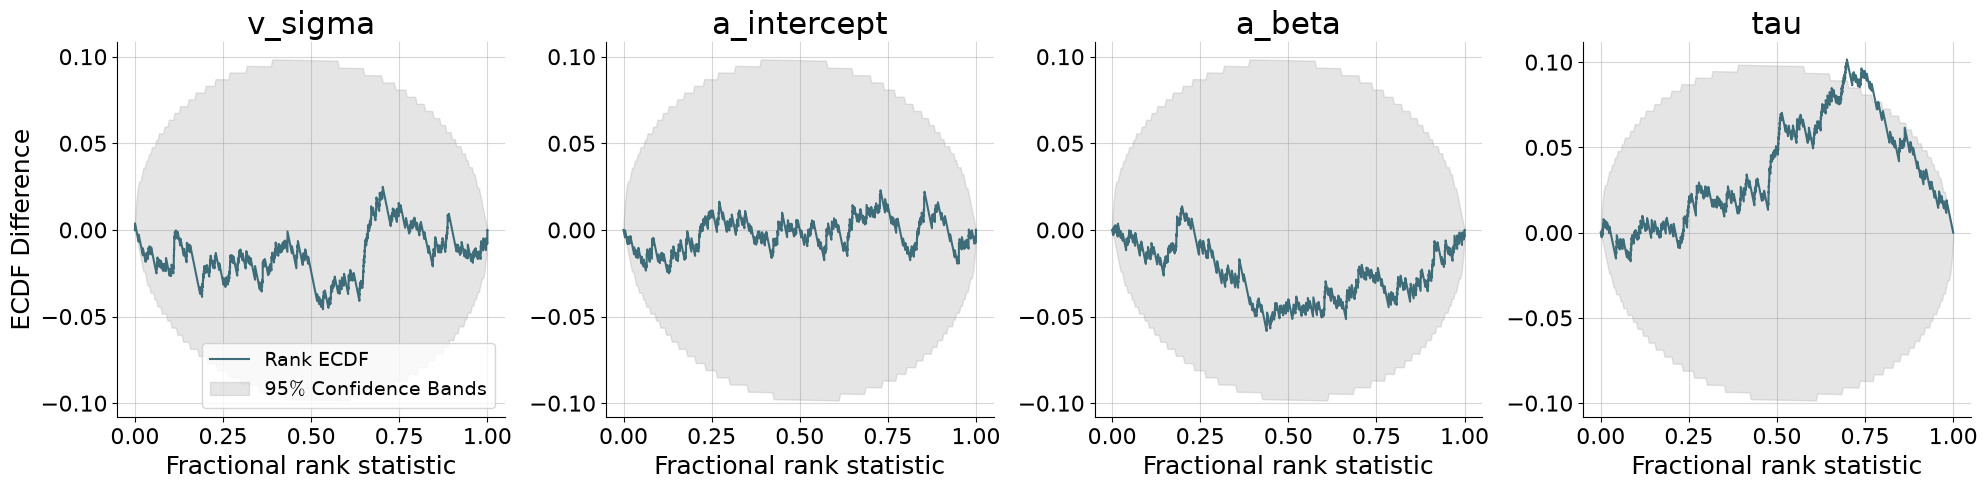

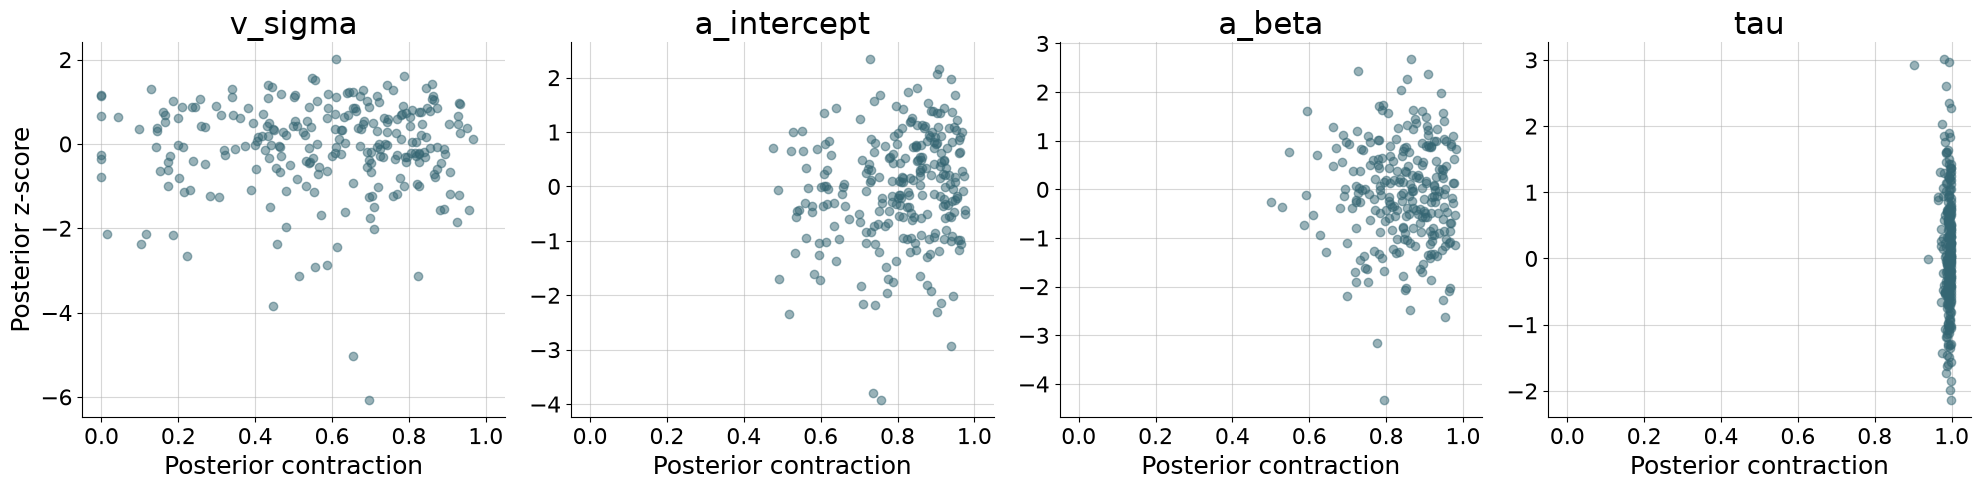

In [23]:
fig_recovery, fig_calibration, fig_z_score_contraction = workflow.verify_time_invariant(
    estimates=samples,
    targets=targets,
    uncertainty_agg=None
)

## Fit Data

To fit empirical data, preserve trial order and format the observations exactly like the simulator output—for this DDM, named response-time and choice arrays with the expected batch and trial dimensions. `workflow.prepare_data()` can help adapt the arrays before they are passed to `workflow.sample()`. The empirical sequence length, coding of choices, missing-value handling, and preprocessing must agree with the choices used during training. For this self-contained demonstration, the cell below uses newly simulated data as a placeholder for 50 participants.

In [25]:
num_subject = 50

data = model.sample(
    batch_size=num_subject,
    num_steps=NUM_STEPS
)

In [ ]:
samples = workflow.sample(
    data=data,
    num_samples=500
)

## Posterior Re-simulation

Posterior re-simulation is a posterior-predictive check: draw parameters from each fitted posterior, simulate new datasets, and compare those predictions with the fitted data. Agreement in response-time distributions, choice proportions, and temporal patterns indicates that the fitted model can reproduce important features of the observations; systematic discrepancies point to model misspecification. `num_sims=5` requests five posterior draws—and therefore five replicated datasets—for every batch element. Increase it for more stable predictive summaries.

In [27]:
resim_data = workflow.resimulate(
    samples,
    num_sims=5
)

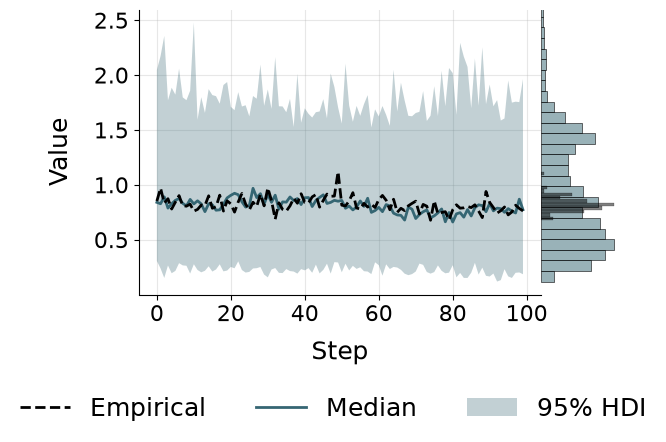

In [29]:
fig = sup.diagnostics.plot_posterior_resimulation(
    prediction=resim_data,
    empirical=data,
    aggregation=np.median,
    aggregate_strategy="no_epistemic",
)

## Posterior Estimates

### Time-varying Parameters

Plot the posterior trajectories for the non-stationary parameters. The median (`aggregation=np.median`) provides a compact trajectory estimate, while the spread of posterior draws should be retained when judging whether apparent fluctuations are credibly different from uncertainty.

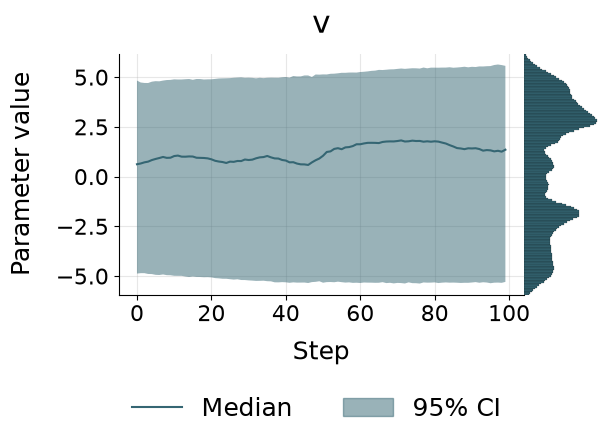

In [30]:
fig = workflow.plot_time_varying_posterior(
    estimates=samples,
    aggregation=np.median
)

### Time-invariant Parameters

Plot the posteriors for shared parameters and transition hyperparameters. Median aggregation summarizes each posterior, but interval estimates or posterior draws should also be reported whenever uncertainty is scientifically relevant.

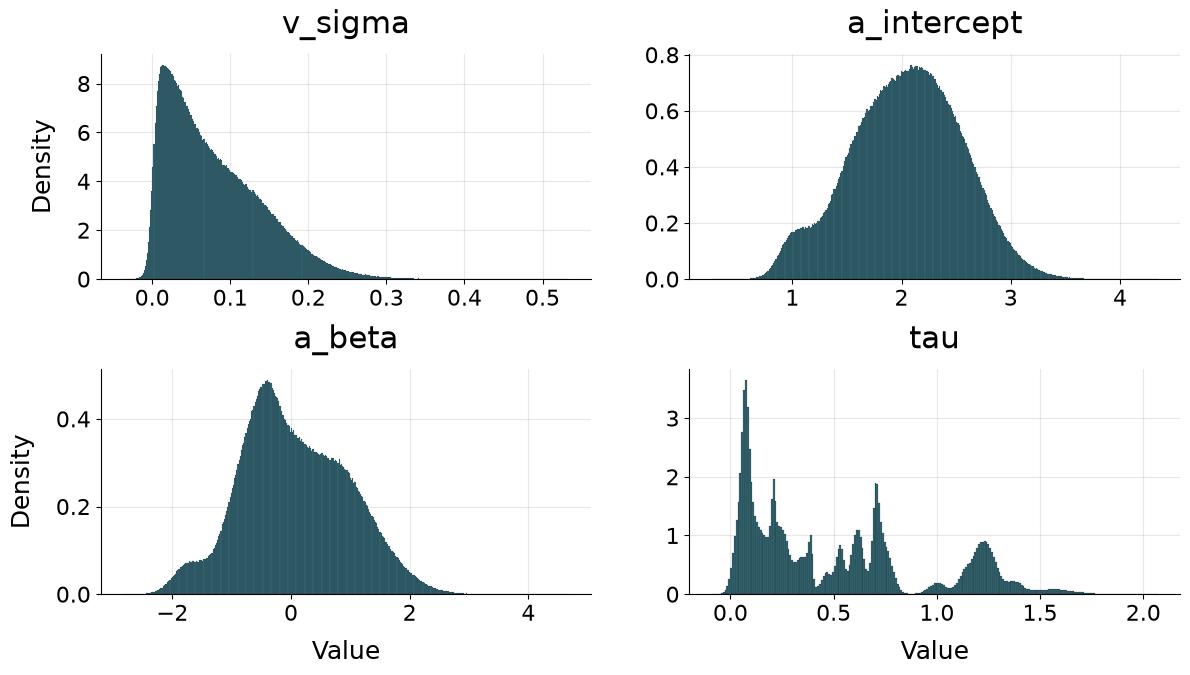

In [31]:
fig = workflow.plot_time_invariant_posterior(
    estimates=samples,
    aggregation=np.median
)